## 0. Loading

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create directories if they don't exist
os.makedirs('./data', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Setup complete.")

# Load all CSV files
print("Loading data files...")

df = pd.read_csv('./data/CDC Diabetes Dataset.csv')
print(f"CDC Diabetes Dataset: {df.shape}")

print("\nData loading complete.")

Setup complete.
Loading data files...
CDC Diabetes Dataset: (253680, 22)

Data loading complete.


## 1. Data Preparation

In [2]:
# Features to use for clustering (excluding target label, near-constant features, socio-economic features, and medical accessibility features)
# Keeping only lifestyle and health indicators
cluster_features = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'HeartDiseaseorAttack',    
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Sex',
    'Age',
]

# Stroke deleted as near-constant (96% no stroke)
# CholCheck AnyHealthcare NoDocbcCost deleted as medical access features
# Education Income deleted as socio-economic features

# Future test: HeartDiseaseorAttack
# This feature may change clustering from lifestyle and health indicators to more medical-based clusters, but it is a strong indicator of diabetes risk and may be useful for identifying high-risk groups.
# First test clustering with and without this feature to see its impact on cluster formation and interpretability.

## Experiment A: without deduplication, with HeartDiseaseorAttack

In [3]:
## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster = df[cluster_features]
X_cluster_scaled = RobustScaler().fit_transform(X_cluster)

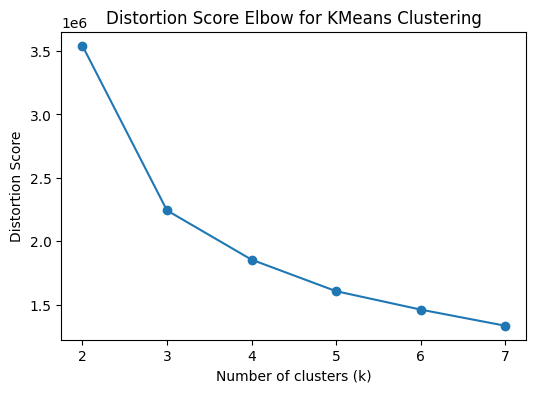

In [4]:
from sklearn.cluster import KMeans

inertias = []
K = range(2, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()


Silhouette scores for different k values:

k = 2 | silhouette score = 0.6471
k = 3 | silhouette score = 0.5979
k = 4 | silhouette score = 0.5942
k = 5 | silhouette score = 0.4941
k = 6 | silhouette score = 0.2087
k = 7 | silhouette score = 0.1992


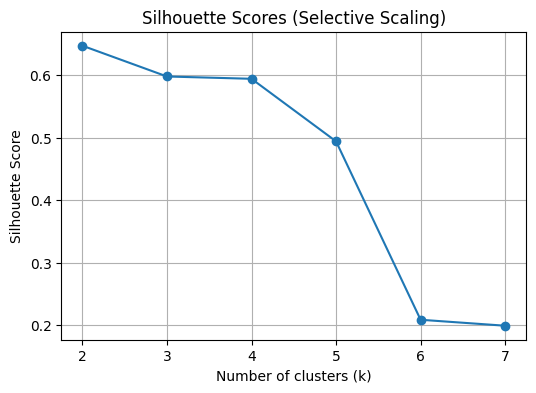

In [5]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled, labels, sample_size=20000, random_state=42)
    sil_scores.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

Silhouette score method indicates the best options would be 2, 3 or 4 clusters. Start with 3 clusters and check interpretability. 

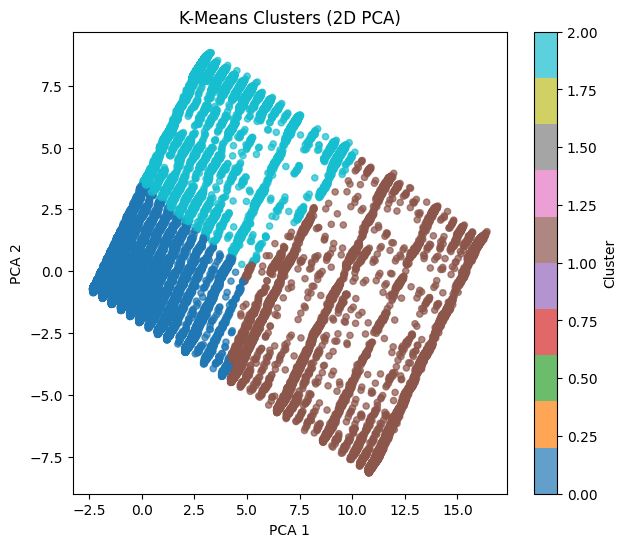

In [6]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df['cluster'] = clusters

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA)")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                        PC1    PC2
MentHlth              0.871 -0.488
PhysHlth              0.471  0.854
GenHlth               0.123  0.153
DiffWalk              0.035  0.050
BMI                   0.030  0.032
PhysActivity         -0.020 -0.025
Smoker                0.015  0.012
HighBP                0.014  0.029
HighChol              0.013  0.019
Sex                  -0.010  0.003
Fruits               -0.009 -0.001
HeartDiseaseorAttack  0.009  0.018
Veggies              -0.007 -0.005
Age                  -0.007  0.057
HvyAlcoholConsump     0.001 -0.004


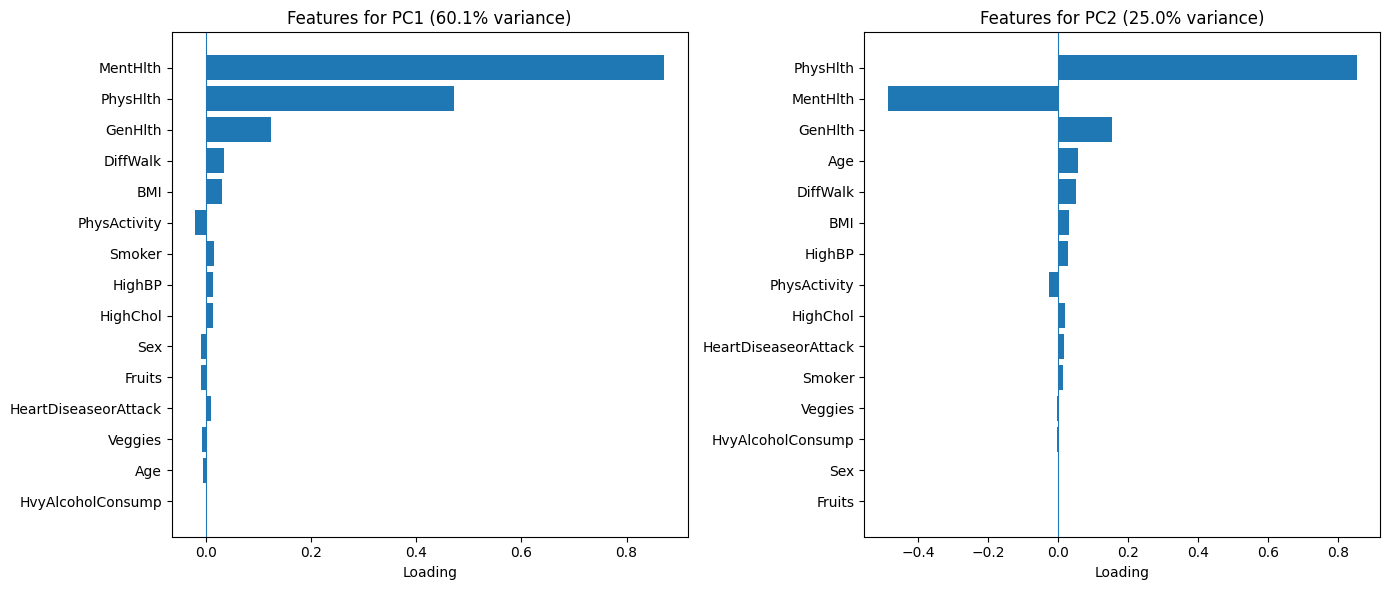

In [7]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [8]:
df.groupby('cluster')[cluster_features].mean().round(3)

,HighBP,HighChol,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
cluster,,,,,,,,,,,,,,,
0,0.398,0.400,28.019,0.415,0.074,0.797,0.647,0.823,0.057,2.278,0.900,0.995,0.097,0.454,7.984
1,0.511,0.510,29.979,0.575,0.147,0.607,0.544,0.747,0.070,3.381,24.723,12.090,0.402,0.346,7.358
2,0.616,0.552,30.016,0.563,0.218,0.550,0.608,0.770,0.038,3.709,2.568,24.882,0.563,0.408,9.085


C:\Users\kevin\AppData\Local\Temp\ipykernel_53760\1758435964.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


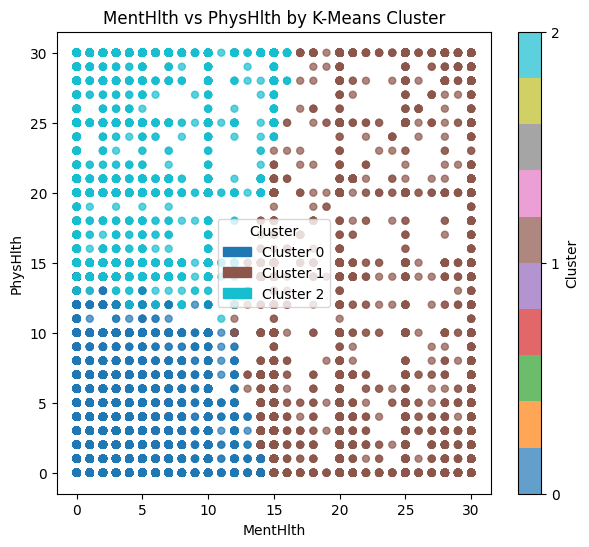

In [9]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['MentHlth'],
    df['PhysHlth'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('MentHlth')
plt.ylabel('PhysHlth')
plt.title('MentHlth vs PhysHlth by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_53760\1853615392.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


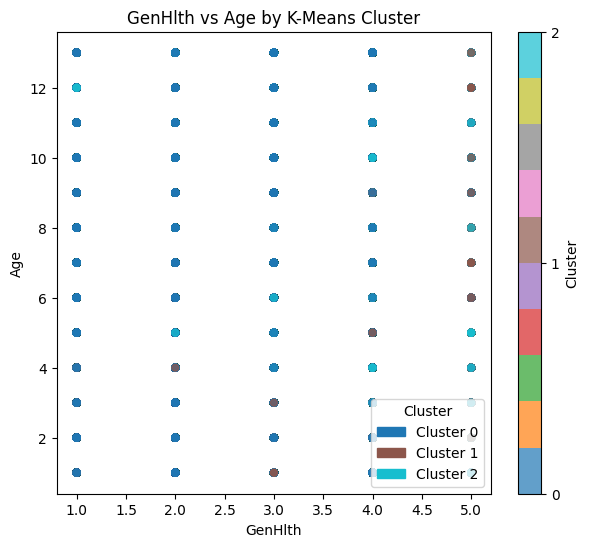

In [10]:
plt.figure(figsize=(7,6))
plt.scatter(
    df['GenHlth'],
    df['Age'],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('GenHlth')
plt.ylabel('Age')
plt.title('GenHlth vs Age by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

## Experiment B: with deduplication, with HeartDiseaseorAttack

Deduplication is applied only in Experiment B to assess its impact onclustering structure. Duplicates are defined as fully identical rows. Due to the absence of key identifier, duplicates can be different individuals with same value across all variables. 

In [11]:
df = pd.read_csv('./data/CDC Diabetes Dataset.csv')

df_dedup = df.drop_duplicates().reset_index(drop=True)

cluster_features = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'HeartDiseaseorAttack',    
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Sex',
    'Age',
]

## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster_dedup = df_dedup[cluster_features]
X_cluster_scaled_dedup = RobustScaler().fit_transform(X_cluster_dedup)

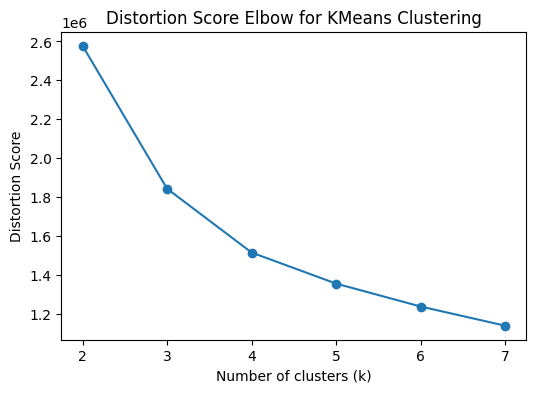

In [12]:
from sklearn.cluster import KMeans

inertias_dedup = []
K = range(2, 8)

for k in K:
    km_dedup = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_dedup.fit(X_cluster_scaled_dedup)
    inertias_dedup.append(km_dedup.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias_dedup, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()

Silhouette scores for different k values:

k = 2 | silhouette score = 0.6577
k = 3 | silhouette score = 0.5258
k = 4 | silhouette score = 0.5225
k = 5 | silhouette score = 0.4836
k = 6 | silhouette score = 0.1896
k = 7 | silhouette score = 0.1927


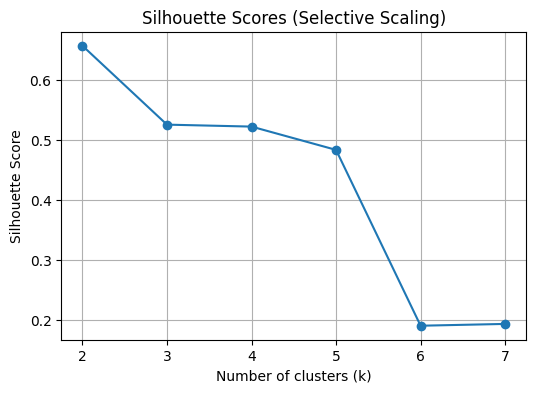

In [13]:
from sklearn.metrics import silhouette_score

sil_scores_dedup = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km_dedup = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_dedup.fit_predict(X_cluster_scaled_dedup)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled_dedup, labels, sample_size=20000, random_state=42)
    sil_scores_dedup.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores_dedup, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

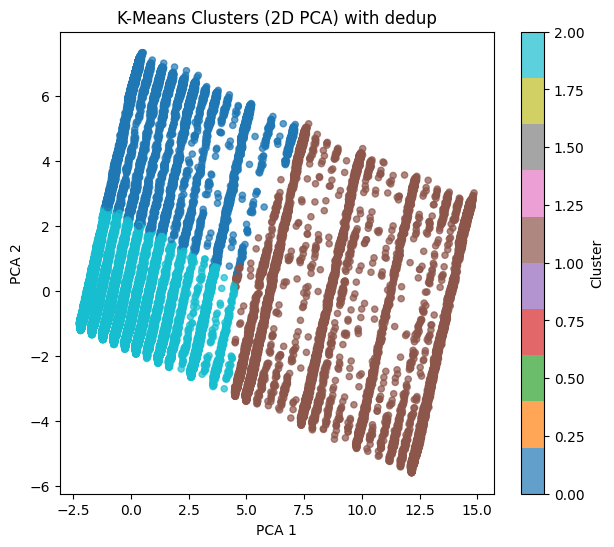

In [14]:
from sklearn.decomposition import PCA

kmeans_dedup = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_dedup = kmeans_dedup.fit_predict(X_cluster_scaled_dedup)
df_dedup['cluster'] = clusters_dedup

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster_scaled_dedup)

plt.figure(figsize=(7,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=df_dedup['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA) with dedup")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                        PC1    PC2
MentHlth              0.955 -0.294
PhysHlth              0.277  0.914
GenHlth               0.100  0.245
DiffWalk              0.028  0.076
BMI                   0.019  0.044
PhysActivity         -0.015 -0.038
Age                  -0.015  0.072
Smoker                0.012  0.019
Sex                  -0.011  0.000
HighChol              0.009  0.029
HighBP                0.008  0.042
Fruits               -0.007 -0.002
HeartDiseaseorAttack  0.006  0.026
Veggies              -0.005 -0.007
HvyAlcoholConsump     0.000 -0.006


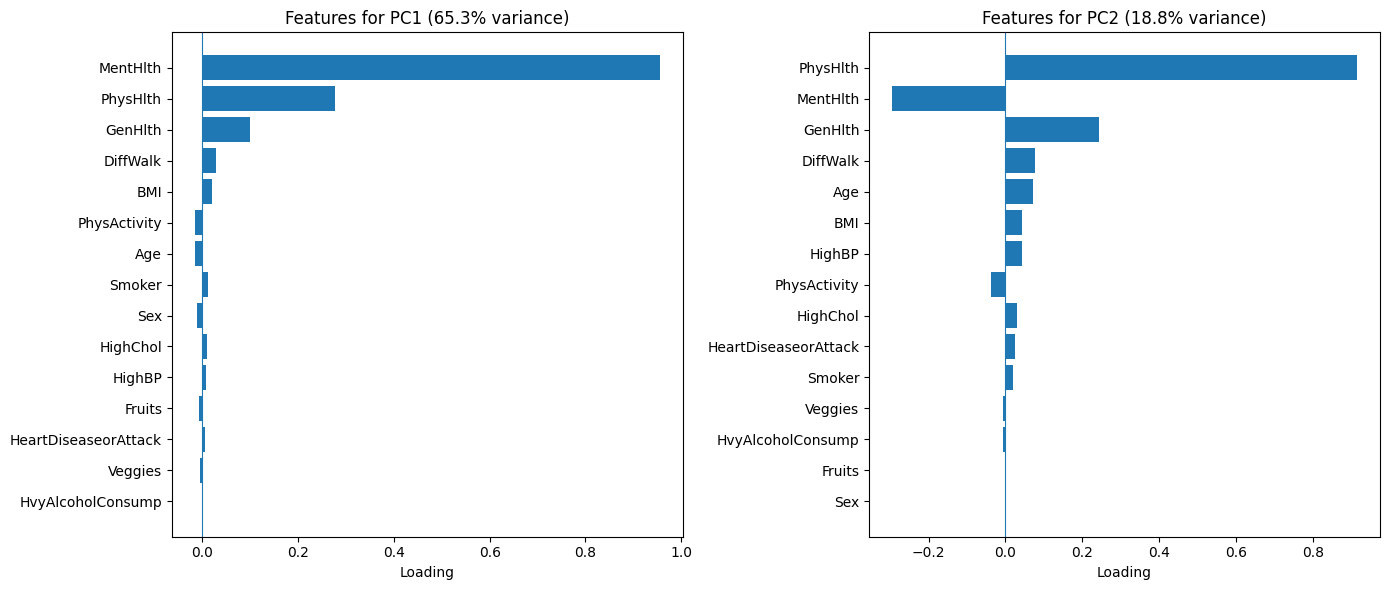

In [15]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster_dedup.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=[f"PC{i+1}" for i in range(pca2.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [16]:
df_dedup.groupby('cluster')[cluster_features].mean().round(3)

,HighBP,HighChol,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
cluster,,,,,,,,,,,,,,,
0,0.620,0.553,30.025,0.563,0.221,0.549,0.609,0.770,0.038,3.722,1.886,24.767,0.566,0.410,9.145
1,0.515,0.511,29.984,0.575,0.150,0.603,0.545,0.747,0.069,3.406,24.002,12.808,0.413,0.346,7.390
2,0.426,0.419,28.350,0.439,0.083,0.773,0.622,0.804,0.062,2.357,0.971,1.145,0.109,0.455,8.050


## Experiment C: without MentHlth PhysHlth and GenHlth

It can be observed that the clustering results are dominated by MentHlth, PhysHlth, and GenHlth. These variables represent self-reported health status rather than direct lifestyle behaviours or objective health indicators. The following experiment removes these variables to examine the influence of these subjective variables on the clustering structure.

In [17]:
df = pd.read_csv('./data/CDC Diabetes Dataset.csv')

df_no_subj = df

cluster_features_no_subj = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'HeartDiseaseorAttack',    
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'DiffWalk',
    'Sex',
    'Age',
]

## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster_no_subj = df_no_subj[cluster_features_no_subj]
X_cluster_scaled_no_subj = RobustScaler().fit_transform(X_cluster_no_subj)

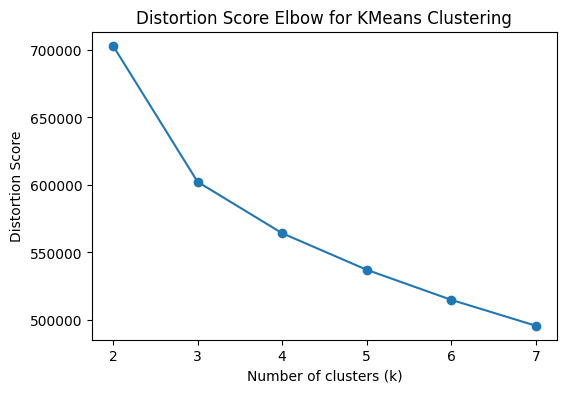

In [18]:
from sklearn.cluster import KMeans

inertias_no_subj = []
K = range(2, 8)

for k in K:
    km_no_subj = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_no_subj.fit(X_cluster_scaled_no_subj)
    inertias_no_subj.append(km_no_subj.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias_no_subj, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()

Silhouette scores for different k values:

k = 2 | silhouette score = 0.1778
k = 3 | silhouette score = 0.1543
k = 4 | silhouette score = 0.1210
k = 5 | silhouette score = 0.1146
k = 6 | silhouette score = 0.1086
k = 7 | silhouette score = 0.1059


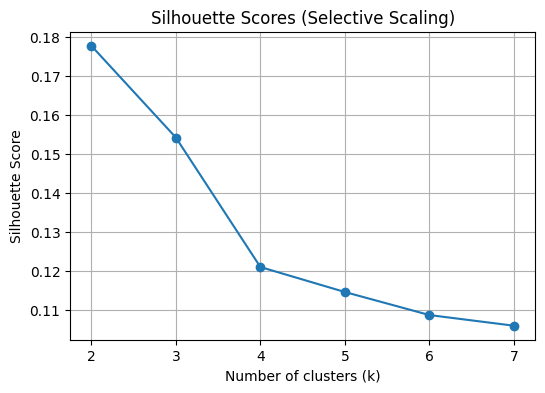

In [19]:
from sklearn.metrics import silhouette_score

sil_scores_no_subj = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km_no_subj = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_no_subj.fit_predict(X_cluster_scaled_no_subj)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled_no_subj, labels, sample_size=20000, random_state=42)
    sil_scores_no_subj.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores_no_subj, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

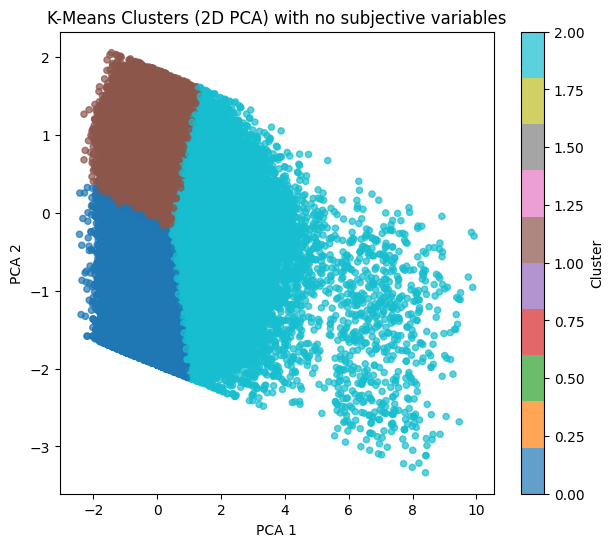

In [20]:
from sklearn.decomposition import PCA

kmeans_no_subj = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_no_subj = kmeans_no_subj.fit_predict(X_cluster_scaled_no_subj)
df_no_subj['cluster'] = clusters_no_subj

pca3 = PCA(n_components=2, random_state=42)
X_pca3 = pca3.fit_transform(X_cluster_scaled_no_subj)

plt.figure(figsize=(7,6))
plt.scatter(X_pca3[:,0], X_pca3[:,1], c=df_no_subj['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA) with no subjective variables")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                        PC1    PC2
BMI                   0.961 -0.162
HighBP                0.177  0.295
DiffWalk              0.109  0.124
HighChol              0.107  0.257
PhysActivity         -0.099 -0.074
Fruits               -0.067  0.034
Age                   0.056  0.878
Veggies              -0.042 -0.013
HeartDiseaseorAttack  0.035  0.104
Sex                   0.033 -0.011
Smoker                0.033  0.130
HvyAlcoholConsump    -0.012 -0.005


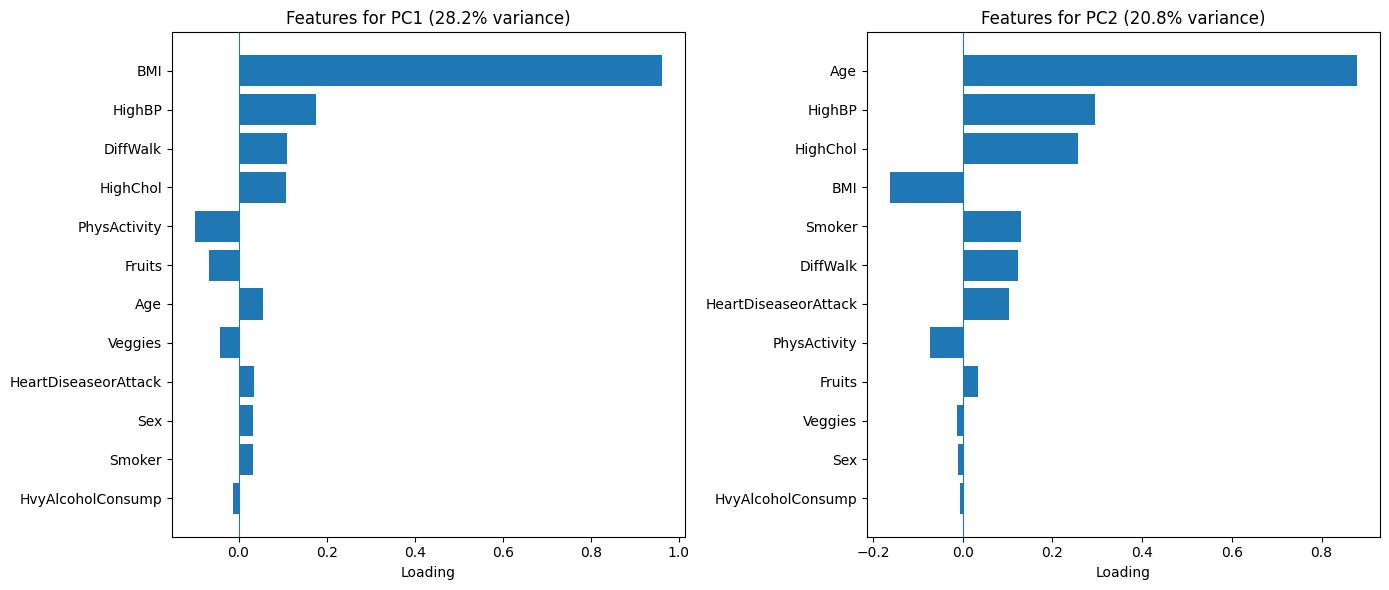

In [21]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster_no_subj.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca3.components_.T,
    columns=[f"PC{i+1}" for i in range(pca3.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca3.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca3.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [22]:
df_no_subj.groupby('cluster')[cluster_features_no_subj].mean().round(3)

,HighBP,HighChol,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
cluster,,,,,,,,,,,,
0,0.106,0.169,25.831,0.322,0.012,0.849,0.648,0.843,0.065,0.040,0.433,5.247
1,0.593,0.584,26.365,0.529,0.148,0.747,0.663,0.810,0.057,0.200,0.455,10.304
2,0.653,0.525,38.685,0.464,0.122,0.596,0.532,0.751,0.037,0.342,0.419,7.758


C:\Users\kevin\AppData\Local\Temp\ipykernel_53760\21787846.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


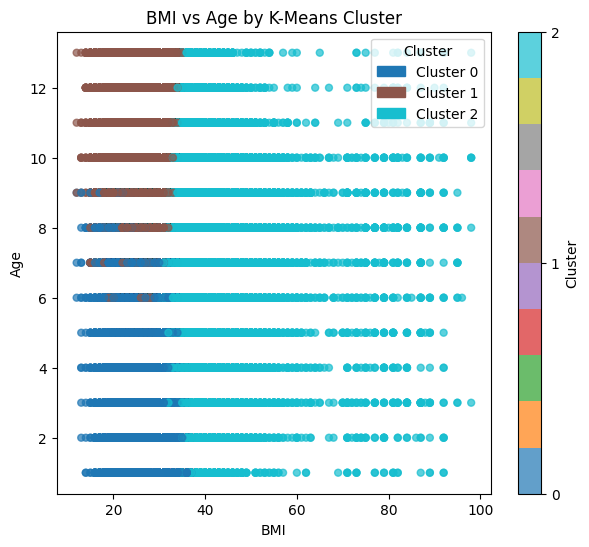

In [23]:
plt.figure(figsize=(7,6))
plt.scatter(
    df_no_subj['BMI'],
    df_no_subj['Age'],
    c=df_no_subj['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('Age')
plt.title('BMI vs Age by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df_no_subj['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_53760\455332742.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(clusters))


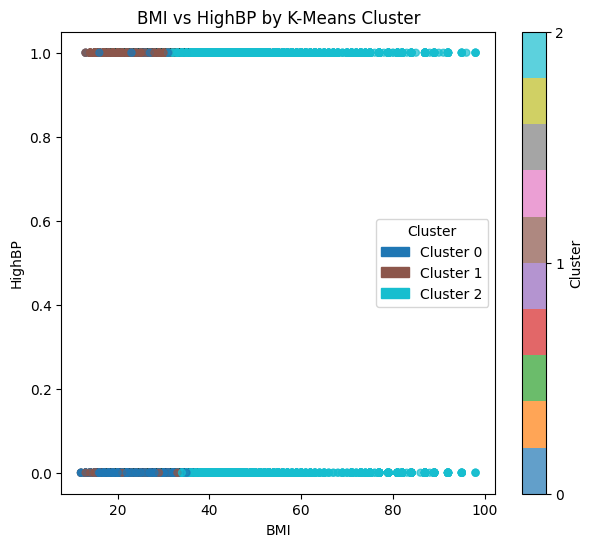

In [24]:
plt.figure(figsize=(7,6))
plt.scatter(
    df_no_subj['BMI'],
    df_no_subj['HighBP'],
    c=df_no_subj['cluster'],
    cmap='tab10',
    alpha=0.7,
    s=25
)

plt.xlabel('BMI')
plt.ylabel('HighBP')
plt.title('BMI vs HighBP by K-Means Cluster')

import matplotlib.cm as cm
import matplotlib.patches as mpatches
clusters = sorted(df_no_subj['cluster'].unique())
cmap = cm.get_cmap('tab10', len(clusters))

handles = [
    mpatches.Patch(color=cmap(i), label=f'Cluster {i}')
    for i in clusters
]

plt.legend(handles=handles, title='Cluster')

cbar = plt.colorbar(label='Cluster')
cbar.set_ticks(sorted(df['cluster'].unique()))

plt.show()

## Experiment D: without MentHlth PhysHlth and GenHlth, and without HeartDiseaseorAttack

In [25]:
df = pd.read_csv('./data/CDC Diabetes Dataset.csv')

df_no_subj_no_heart = df

cluster_features_no_subj_no_heart = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'DiffWalk',
    'Sex',
    'Age',
]

## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster_no_subj_no_heart = df_no_subj_no_heart[cluster_features_no_subj_no_heart]
X_cluster_scaled_no_subj_no_heart = RobustScaler().fit_transform(X_cluster_no_subj_no_heart)

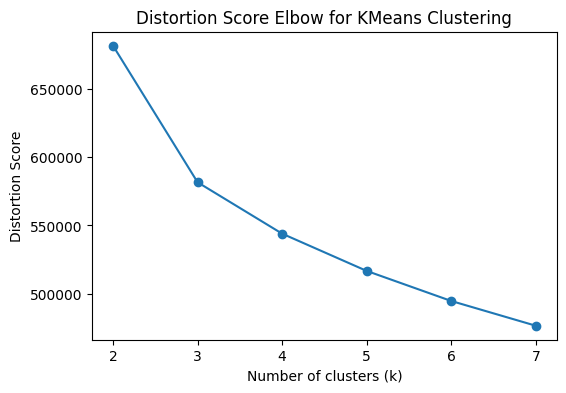

In [26]:
from sklearn.cluster import KMeans

inertias_no_subj_no_heart = []
K = range(2, 8)

for k in K:
    km_no_subj_no_heart = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_no_subj_no_heart.fit(X_cluster_scaled_no_subj_no_heart)
    inertias_no_subj_no_heart.append(km_no_subj_no_heart.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias_no_subj_no_heart, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()

Silhouette scores for different k values:

k = 2 | silhouette score = 0.1832
k = 3 | silhouette score = 0.1581
k = 4 | silhouette score = 0.1248
k = 5 | silhouette score = 0.1186
k = 6 | silhouette score = 0.1112
k = 7 | silhouette score = 0.1105


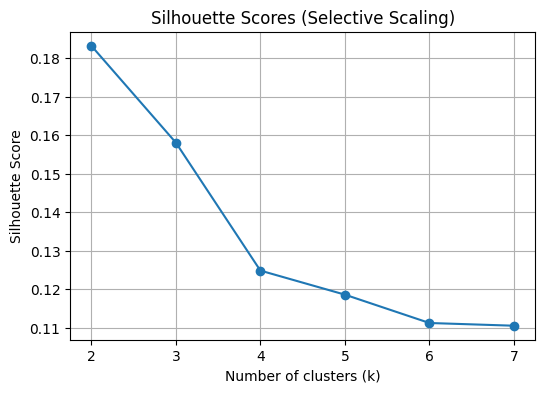

In [27]:
from sklearn.metrics import silhouette_score

sil_scores_no_subj_no_heart = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km_no_subj_no_heart = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_no_subj_no_heart.fit_predict(X_cluster_scaled_no_subj_no_heart)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled_no_subj_no_heart, labels, sample_size=20000, random_state=42)
    sil_scores_no_subj_no_heart.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores_no_subj_no_heart, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

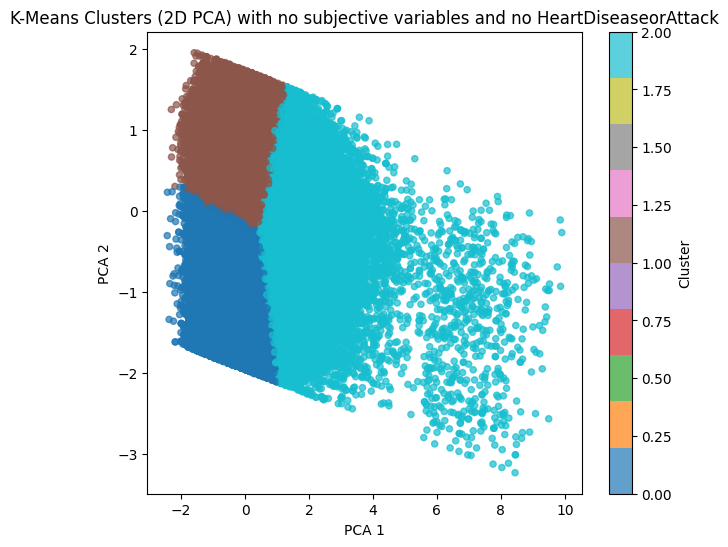

In [28]:
from sklearn.decomposition import PCA

kmeans_no_subj_no_heart = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_no_subj_no_heart = kmeans_no_subj_no_heart.fit_predict(X_cluster_scaled_no_subj_no_heart)
df_no_subj_no_heart['cluster'] = clusters_no_subj_no_heart

pca4 = PCA(n_components=2, random_state=42)
X_pca4 = pca4.fit_transform(X_cluster_scaled_no_subj_no_heart)

plt.figure(figsize=(7,6))
plt.scatter(X_pca4[:,0], X_pca4[:,1], c=df_no_subj_no_heart['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA) with no subjective variables and no HeartDiseaseorAttack")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                     PC1    PC2
BMI                0.963 -0.149
HighBP             0.174  0.297
DiffWalk           0.108  0.123
HighChol           0.105  0.258
PhysActivity      -0.098 -0.075
Fruits            -0.067  0.035
Age                0.048  0.886
Veggies           -0.042 -0.013
Sex                0.033 -0.014
Smoker             0.031  0.129
HvyAlcoholConsump -0.012 -0.005


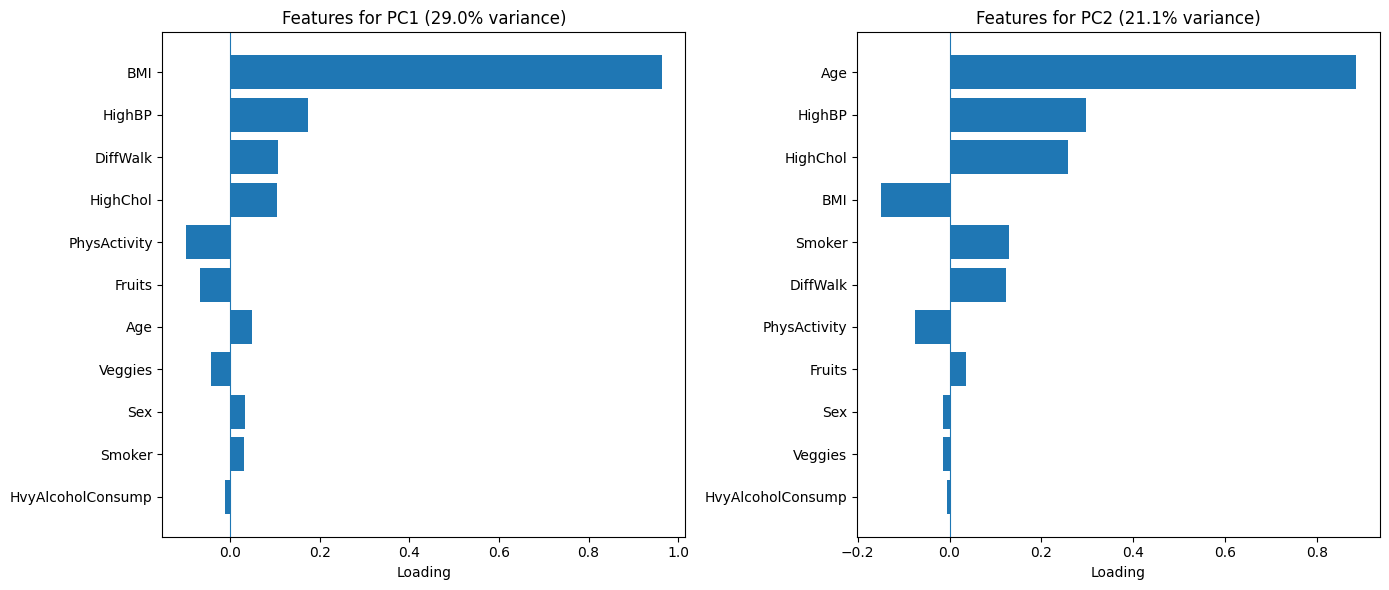

In [29]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster_no_subj_no_heart.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca4.components_.T,
    columns=[f"PC{i+1}" for i in range(pca4.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca4.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca4.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [30]:
df_no_subj_no_heart.groupby('cluster')[cluster_features_no_subj_no_heart].mean().round(3)

,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
cluster,,,,,,,,,,,
0,0.106,0.163,25.803,0.323,0.849,0.647,0.843,0.065,0.040,0.434,5.204
1,0.587,0.583,26.352,0.526,0.749,0.664,0.811,0.057,0.197,0.454,10.283
2,0.652,0.526,38.621,0.465,0.597,0.533,0.751,0.037,0.343,0.419,7.759


Without HeartDiseaseorAttack, there is nearly no change on other variables, meaning it does not drive the clustering structure. Semantically, this variable is more of a downstream health outcome instead of a risk factor. Also, only fewer than 10% of the sample report a history of heart disease, and this low prevalence further supports its limited influence on the overall clustering structure.

## Experiment E: Experiment D with deduplication

In [31]:
df = pd.read_csv('./data/CDC Diabetes Dataset.csv')

df_no_subj_no_heart_2 = df.drop_duplicates().reset_index(drop=True)

cluster_features_no_subj_no_heart_2 = [    
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'DiffWalk',
    'Sex',
    'Age',
]

## Scale features for clustering (RobustScaler to handle outliers in BMI and health indicators)
from sklearn.preprocessing import RobustScaler

X_cluster_no_subj_no_heart_2 = df_no_subj_no_heart_2[cluster_features_no_subj_no_heart_2]
X_cluster_scaled_no_subj_no_heart_2 = RobustScaler().fit_transform(X_cluster_no_subj_no_heart_2)

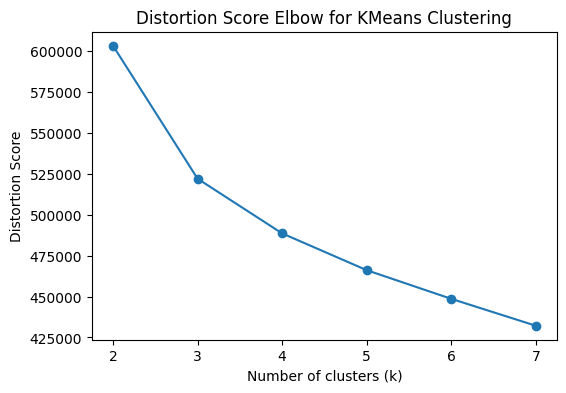

In [32]:
from sklearn.cluster import KMeans

inertias_no_subj_no_heart_2 = []
K = range(2, 8)

for k in K:
    km_no_subj_no_heart_2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_no_subj_no_heart_2.fit(X_cluster_scaled_no_subj_no_heart_2)
    inertias_no_subj_no_heart_2.append(km_no_subj_no_heart_2.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias_no_subj_no_heart_2, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Distortion Score")
plt.title("Distortion Score Elbow for KMeans Clustering")
plt.show()

Silhouette scores for different k values:

k = 2 | silhouette score = 0.1484
k = 3 | silhouette score = 0.1549
k = 4 | silhouette score = 0.1229
k = 5 | silhouette score = 0.1164
k = 6 | silhouette score = 0.1094
k = 7 | silhouette score = 0.1076


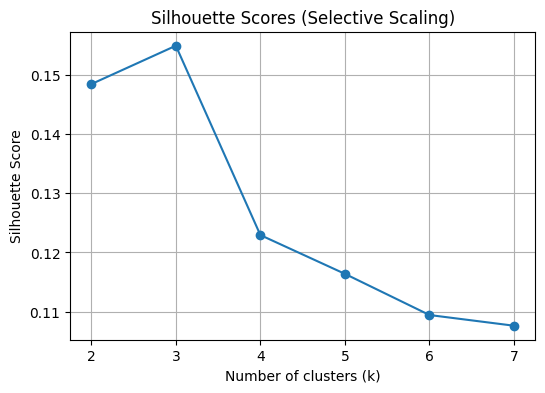

In [33]:
from sklearn.metrics import silhouette_score

sil_scores_no_subj_no_heart_2 = []
K = range(2, 8)

print("Silhouette scores for different k values:\n")

for k in K:
    km_no_subj_no_heart_2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_no_subj_no_heart_2.fit_predict(X_cluster_scaled_no_subj_no_heart_2)
    # due to O(n²) cost, estimating silhouette on a random subset of 20000 samples
    score = silhouette_score(X_cluster_scaled_no_subj_no_heart_2, labels, sample_size=20000, random_state=42)
    sil_scores_no_subj_no_heart_2.append(score)
    print(f"k = {k} | silhouette score = {score:.4f}")

plt.figure(figsize=(6,4))
plt.plot(list(K), sil_scores_no_subj_no_heart_2, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (Selective Scaling)")
plt.grid(True)
plt.show()

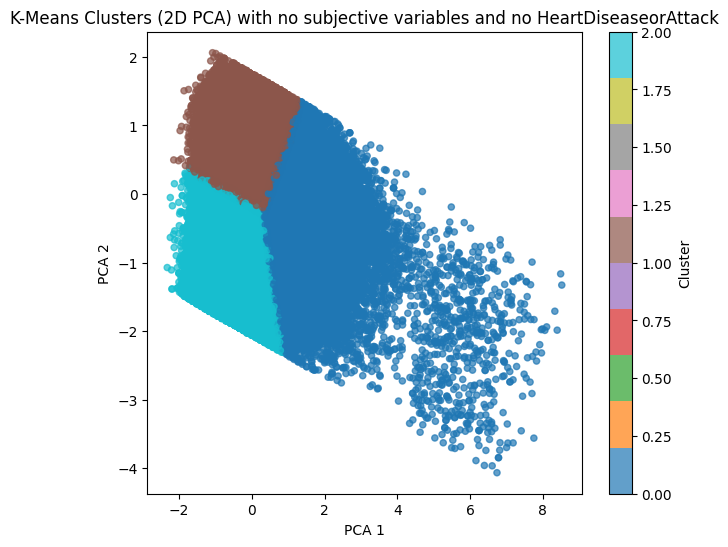

In [34]:
from sklearn.decomposition import PCA

kmeans_no_subj_no_heart_2 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_no_subj_no_heart_2 = kmeans_no_subj_no_heart_2.fit_predict(X_cluster_scaled_no_subj_no_heart_2)
df_no_subj_no_heart_2['cluster'] = clusters_no_subj_no_heart_2

pca5 = PCA(n_components=2, random_state=42)
X_pca5 = pca5.fit_transform(X_cluster_scaled_no_subj_no_heart_2)

plt.figure(figsize=(7,6))
plt.scatter(X_pca5[:,0], X_pca5[:,1], c=df_no_subj_no_heart_2['cluster'], cmap='tab10', alpha=0.7, s=20)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (2D PCA) with no subjective variables and no HeartDiseaseorAttack")
plt.colorbar(label="Cluster")
plt.show()

PCA Loadings (Feature Contributions):
                     PC1    PC2
BMI                0.925 -0.283
HighBP             0.232  0.259
Age                0.168  0.877
HighChol           0.146  0.229
DiffWalk           0.140  0.108
PhysActivity      -0.116 -0.053
Fruits            -0.058  0.058
Veggies           -0.041  0.000
Smoker             0.032  0.109
Sex                0.026 -0.024
HvyAlcoholConsump -0.019 -0.006


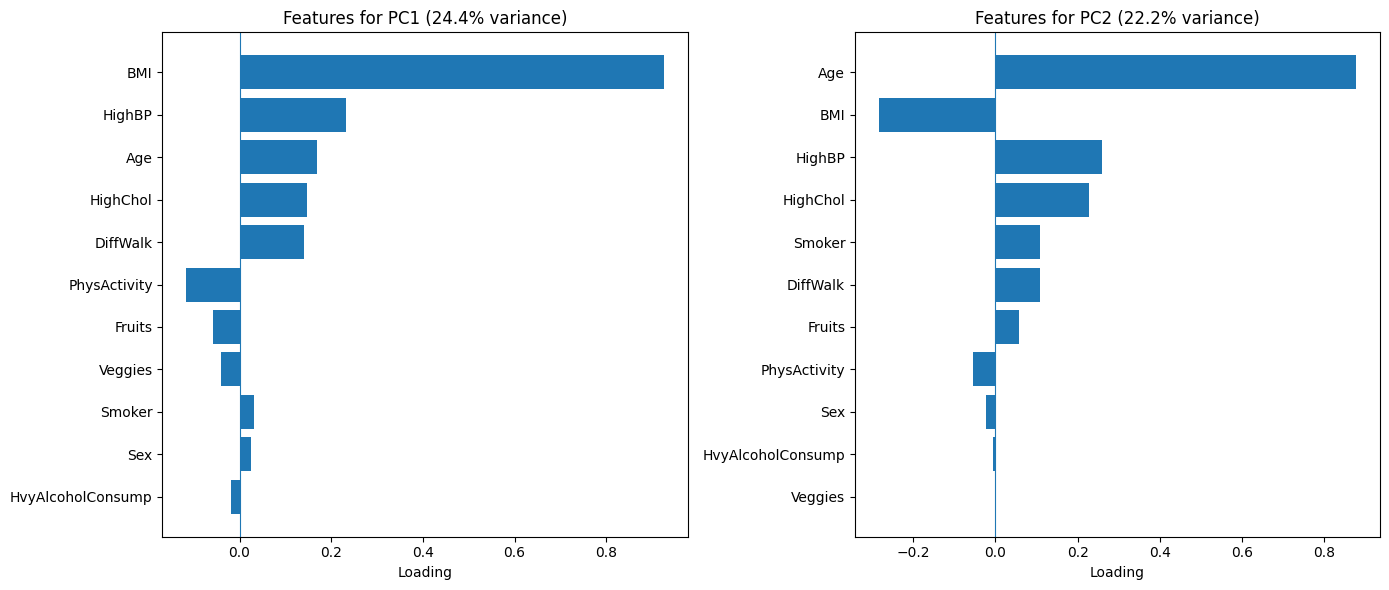

In [35]:
# 1) 取特征名：优先用 X.columns（因为 PCA 就是 fit 在 X 上）
feature_names = X_cluster_no_subj_no_heart_2.columns

# 2) PCA loadings：components_.T 形状是 (n_features, n_components)
loadings = pd.DataFrame(
    pca5.components_.T,
    columns=[f"PC{i+1}" for i in range(pca5.n_components_)],
    index=feature_names
)

# 3) 按 PC1 绝对值排序输出
loadings_sorted = loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# 4) 可视化：分别画 PC1 / PC2 的所有特征（或你想要 top k）
n_features = len(feature_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1
axes[0].barh(range(n_features), loadings_sorted["PC1"])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(loadings_sorted.index)
axes[0].invert_yaxis()
axes[0].set_xlabel("Loading")
axes[0].set_title(f"Features for PC1 ({pca5.explained_variance_ratio_[0]:.1%} variance)")
axes[0].axvline(x=0, linewidth=0.8)

# PC2
loadings_sorted_pc2 = loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index)
axes[1].barh(range(n_features), loadings_sorted_pc2["PC2"])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(loadings_sorted_pc2.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("Loading")
axes[1].set_title(f"Features for PC2 ({pca5.explained_variance_ratio_[1]:.1%} variance)")
axes[1].axvline(x=0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [36]:
df_no_subj_no_heart_2.groupby('cluster')[cluster_features_no_subj_no_heart_2].mean().round(3)

,HighBP,HighChol,BMI,Smoker,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Sex,Age
cluster,,,,,,,,,,,
0,0.684,0.547,39.013,0.470,0.575,0.524,0.744,0.036,0.370,0.411,7.863
1,0.585,0.571,26.405,0.523,0.739,0.653,0.801,0.060,0.209,0.444,10.297
2,0.131,0.189,26.349,0.377,0.813,0.602,0.814,0.076,0.048,0.448,4.902


Upon inspection, deduplication does not change the clustering profile by much. Thus, the proceeding modelling continue with duplicates kept, to preserve the represented population. This means, dupulications without key identifier are considered as individuals with mutual values to variables instead of duplicated error. 